In [2]:
import os
os.getcwd()
os.chdir('../')

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
# Reading Data
team_salary=pd.read_csv('Datasets/team_salary.csv')
team_salary.head()

,Team_ID,Team_Name,Win_Percent,Average_Salary
0,ARI,Arizona Diamondbacks,57.407407,3.363041e+06
1,ATL,Atlanta Braves,44.444444,2.362010e+06
2,BAL,Baltimore Orioles,46.296296,5.581498e+06
3,BOS,Boston Red Sox,57.407407,6.501578e+06
4,CHA,Chicago White Sox,41.358025,4.519947e+06


In [8]:
# Examining the dataset
print(team_salary.info())

print('----------------------')

print(team_salary.dtypes)

print('----------------------')

print(team_salary.describe())

print('----------------------')

print(team_salary.shape)

print('----------------------')

print(team_salary.columns)

print('----------------------')

print(team_salary.index)

print('----------------------')

print(team_salary.axes)

print('----------------------')

print(team_salary.values)

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Team_ID         30 non-null     str    
 1   Team_Name       30 non-null     str    
 2   Win_Percent     30 non-null     float64
 3   Average_Salary  30 non-null     float64
dtypes: float64(2), str(2)
memory usage: 1.1 KB
None
----------------------
Team_ID               str
Team_Name             str
Win_Percent       float64
Average_Salary    float64
dtype: object
----------------------
       Win_Percent  Average_Salary
count    30.000000    3.000000e+01
mean     50.000000    4.391402e+06
std       7.117943    1.548224e+06
min      39.506173    2.033793e+06
25%      44.907407    3.140934e+06
50%      48.765432    4.526993e+06
75%      55.555556    5.414304e+06
max      64.197531    7.689579e+06
----------------------
(30, 4)
----------------------
Index(['Team_ID', 'Team_Name', 'Win_Percent', 'Averag

In [13]:
# Subset

team_salary[['Team_ID','Team_Name']].head()

,Team_ID,Team_Name
0,ARI,Arizona Diamondbacks
1,ATL,Atlanta Braves
2,BAL,Baltimore Orioles
3,BOS,Boston Red Sox
4,CHA,Chicago White Sox


In [15]:
team_salary.Team_Name.head()

0    Arizona Diamondbacks
1          Atlanta Braves
2       Baltimore Orioles
3          Boston Red Sox
4       Chicago White Sox
Name: Team_Name, dtype: str

In [18]:
team_salary.select_dtypes('number').head()

,Win_Percent,Average_Salary
0,57.407407,3.363041e+06
1,44.444444,2.362010e+06
2,46.296296,5.581498e+06
3,57.407407,6.501578e+06
4,41.358025,4.519947e+06


In [26]:
team_salary.iloc[5,[0]]

Team_ID    CHN
Name: 5, dtype: str

In [27]:
team_salary_index = team_salary.set_index('Team_ID')
team_salary_index.head()

,Team_Name,Win_Percent,Average_Salary
Team_ID,,,
ARI,Arizona Diamondbacks,57.407407,3.363041e+06
ATL,Atlanta Braves,44.444444,2.362010e+06
BAL,Baltimore Orioles,46.296296,5.581498e+06
BOS,Boston Red Sox,57.407407,6.501578e+06
CHA,Chicago White Sox,41.358025,4.519947e+06


In [32]:
team_salary_index.loc['BOS','Average_Salary']

np.float64(6501577.96551724)

In [ ]:
x = team_salary_index.index=='BOS'
x

<method-wrapper '__index__' of numpy.ndarray object at 0x00000123E315F630>

In [44]:
team_salary_index.iloc[(team_salary_index.index=='BOS').shape[0]]

IndexError: single positional indexer is out-of-bounds

In [47]:
team_salary_index.iloc[3,2]

np.float64(6501577.96551724)

In [52]:
# Boolean Subsetting

team_salary.loc[team_salary['Win_Percent'] > 60]

,Team_ID,Team_Name,Win_Percent,Average_Salary
7,CLE,Cleveland Indians,62.962963,2.752293e+06
10,HOU,Houston Astros,62.345679,3.389061e+06
13,LAN,Los Angeles Dodgers,64.197531,6.322525e+06


In [54]:
team_salary.loc[(team_salary['Win_Percent'] > 60) & (team_salary['Average_Salary']<3000000)]

,Team_ID,Team_Name,Win_Percent,Average_Salary
7,CLE,Cleveland Indians,62.962963,2.752293e+06


In [56]:
# Filtering using filter function
team_salary.filter(like='Team',axis=1).head()

,Team_ID,Team_Name
0,ARI,Arizona Diamondbacks
1,ATL,Atlanta Braves
2,BAL,Baltimore Orioles
3,BOS,Boston Red Sox
4,CHA,Chicago White Sox


In [57]:
team_salary.sample(n=21,random_state=617)

,Team_ID,Team_Name,Win_Percent,Average_Salary
11,KCA,Kansas City Royals,49.382716,4.534039e+06
25,SLN,St. Louis Cardinals,51.234568,4.614629e+06
23,SEA,Seattle Mariners,48.148148,4.845834e+06
7,CLE,Cleveland Indians,62.962963,2.752293e+06
0,ARI,Arizona Diamondbacks,57.407407,3.363041e+06
18,NYN,New York Mets,43.209877,4.958857e+06
17,NYA,New York Yankees,56.172840,7.689579e+06
3,BOS,Boston Red Sox,57.407407,6.501578e+06
15,MIL,Milwaukee Brewers,53.086420,2.292508e+06
19,OAK,Oakland Athletics,46.296296,2.893541e+06


In [58]:
team_salary.sample(n=2,axis=1, random_state=617).head()

,Team_Name,Average_Salary
0,Arizona Diamondbacks,3.363041e+06
1,Atlanta Braves,2.362010e+06
2,Baltimore Orioles,5.581498e+06
3,Boston Red Sox,6.501578e+06
4,Chicago White Sox,4.519947e+06


In [59]:
fortune = pd.read_csv(filepath_or_buffer='Datasets/fortune1000_2024.csv', 
                      usecols = ['Rank','Company', 'Ticker', 'Sector', 'Industry','Number_of_employees', 'Revenues_M', 'Profits_M', 'MarketCap_Updated_M', 'Country',
       'HeadquartersCity'] ,index_col='Rank')
fortune.head()

,Company,Ticker,Sector,Industry,Number_of_employees,Revenues_M,Profits_M,Country,HeadquartersCity,MarketCap_Updated_M
Rank,,,,,,,,,,
1,Walmart,WMT,Retailing,General Merchandisers,2100000,648125.0,15511.0,U.S.,Bentonville,559911.0
2,Amazon,AMZN,Retailing,Internet Services and Retailing,1525000,574785.0,30425.0,U.S.,Seattle,2005565.0
3,Apple,AAPL,Technology,"Computers, Office Equipment",161000,383285.0,96995.0,U.S.,Cupertino,3594309.0
4,UnitedHealth Group,UNH,Health Care,Health Care: Insurance and Managed Care,440000,371622.0,22381.0,U.S.,Minnetonka,474339.0
5,Berkshire Hathaway,BRKA,Financials,Insurance: Property and Casualty (Stock),396500,364482.0,96223.0,U.S.,Omaha,937028.0


In [60]:
fortune.iloc[:5,:3]   # First 5 rows
fortune.iloc[1:6:2,:3] # alternating rows
fortune.iloc[:5,[0,1,2,4]]

,Company,Ticker,Sector,Number_of_employees
Rank,,,,
1,Walmart,WMT,Retailing,2100000
2,Amazon,AMZN,Retailing,1525000
3,Apple,AAPL,Technology,161000
4,UnitedHealth Group,UNH,Health Care,440000
5,Berkshire Hathaway,BRKA,Financials,396500


In [61]:
fortune.loc[991:1001,['Company','MarketCap_Updated_M']]

,Company,MarketCap_Updated_M
Rank,,
991,Wabash National,1350.0
992,MSCI,44401.0
993,Stagwell,1670.0
994,Mativ Holdings,1018.0
995,Belden,3805.0
996,Allegiant Travel,1375.0
997,Dropbox,8359.0
998,Exact Sciences,12537.0
999,BWX Technologies,9380.0


In [62]:
fortune_new = fortune.reset_index().set_index('Company')
fortune_new.loc['Walmart',['Number_of_employees','Revenues_M','Profits_M']]

Number_of_employees    2100000.0
Revenues_M              648125.0
Profits_M                15511.0
Name: Walmart, dtype: float64

In [63]:
fortune_new.loc[:,'Number_of_employees':'Profits_M']

,Number_of_employees,Revenues_M,Profits_M
Company,,,
Walmart,2100000,648125.0,15511.0
Amazon,1525000,574785.0,30425.0
Apple,161000,383285.0,96995.0
UnitedHealth Group,440000,371622.0,22381.0
Berkshire Hathaway,396500,364482.0,96223.0
...,...,...,...
Allegiant Travel,6686,2509.9,117.6
Dropbox,2693,2501.6,453.6
Exact Sciences,6550,2499.8,-204.1


In [64]:
# Boolean subsetting multiple coditions

In [65]:
retail = fortune['Sector'] == 'Retailing'
large_revenue = fortune['Revenues_M'] > fortune['Revenues_M'].median()
large_profit =  fortune['Profits_M'] > fortune['Profits_M'].median()
few_employees = fortune['Number_of_employees'] < 20000
fortune.loc[retail & large_revenue & large_profit & few_employees, 'Company']

Rank
214                 Murphy USA
229         Group 1 Automotive
281    Asbury Automotive Group
315              Expedia Group
474            Williams-Sonoma
Name: Company, dtype: str

In [66]:
# Code redability is possible using the \ operator.
team_salary \
    .rename(columns = {'Team_ID': 'team_id', 
                       'Team_Name': 'team'}) \
    .head()

,team_id,team,Win_Percent,Average_Salary
0,ARI,Arizona Diamondbacks,57.407407,3.363041e+06
1,ATL,Atlanta Braves,44.444444,2.362010e+06
2,BAL,Baltimore Orioles,46.296296,5.581498e+06
3,BOS,Boston Red Sox,57.407407,6.501578e+06
4,CHA,Chicago White Sox,41.358025,4.519947e+06


In [68]:
# Alternate option
(
    team_salary
        .rename(columns = {'Team_ID': 'team_id', 
                           'Team_Name': 'team'}) \
        .head()
)

,team_id,team,Win_Percent,Average_Salary
0,ARI,Arizona Diamondbacks,57.407407,3.363041e+06
1,ATL,Atlanta Braves,44.444444,2.362010e+06
2,BAL,Baltimore Orioles,46.296296,5.581498e+06
3,BOS,Boston Red Sox,57.407407,6.501578e+06
4,CHA,Chicago White Sox,41.358025,4.519947e+06


In [70]:
team_salary = pd.read_csv(filepath_or_buffer='Datasets/team_salary.csv')
team_salary_edit = team_salary.copy()
team_salary_edit.head()

,Team_ID,Team_Name,Win_Percent,Average_Salary
0,ARI,Arizona Diamondbacks,57.407407,3.363041e+06
1,ATL,Atlanta Braves,44.444444,2.362010e+06
2,BAL,Baltimore Orioles,46.296296,5.581498e+06
3,BOS,Boston Red Sox,57.407407,6.501578e+06
4,CHA,Chicago White Sox,41.358025,4.519947e+06


In [71]:
team_salary_edit.assign(league_assign = 'mlb').head()

,Team_ID,Team_Name,Win_Percent,Average_Salary,league_assign
0,ARI,Arizona Diamondbacks,57.407407,3.363041e+06,mlb
1,ATL,Atlanta Braves,44.444444,2.362010e+06,mlb
2,BAL,Baltimore Orioles,46.296296,5.581498e+06,mlb
3,BOS,Boston Red Sox,57.407407,6.501578e+06,mlb
4,CHA,Chicago White Sox,41.358025,4.519947e+06,mlb


In [73]:
(
    fortune
        .assign(rev_per_emp=fortune.Revenues_M/fortune.Number_of_employees)
        .rev_per_emp
        .mean()
)

np.float64(1.4057301051589812)

In [77]:
(
    fortune
        .assign(rev_per_emp=fortune.Revenues_M/fortune.Number_of_employees)
        .groupby(by='Sector')
        .rev_per_emp
        .aggregate(['mean','std'])
)

,mean,std
Sector,,
Aerospace & Defense,0.349993,0.077484
Apparel,0.447068,0.210685
Business Services,0.705917,2.115817
Chemicals,0.751858,0.464097
Energy,3.504828,3.378951
Engineering & Construction,1.342040,1.127990
Financials,3.185692,11.306834
Food & Drug Stores,0.768176,1.286002
"Food, Beverages & Tobacco",1.064961,1.254483


<Axes: xlabel='Sector'>

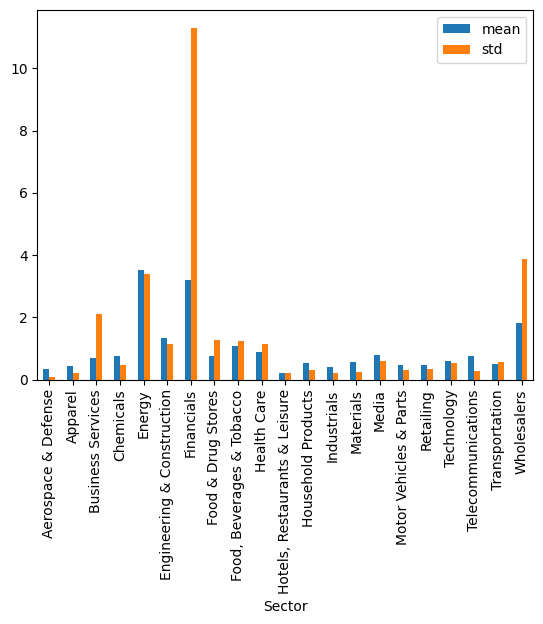

In [81]:
(
    fortune
        .assign(rev_per_emp=fortune.Revenues_M/fortune.Number_of_employees)
        .groupby(by='Sector')
        .rev_per_emp
        .aggregate(['mean','std'])
        .plot(kind='bar')
)